:meth:`SeqMutPlot.mutation_landscape` is the mutation-scan heatmap: the 20 amino-acid substitutions (rows) against the scanned positions (columns, labelled by the wild-type residue and colored by sequence part). When :meth:`SeqMut.scan` ran with a bound ``model``, each cell is the model prediction shift ``delta_pred`` (diverging blue-white-red) and the title reports the wild-type prediction; otherwise the cells show the model-free ``delta_cpp``.

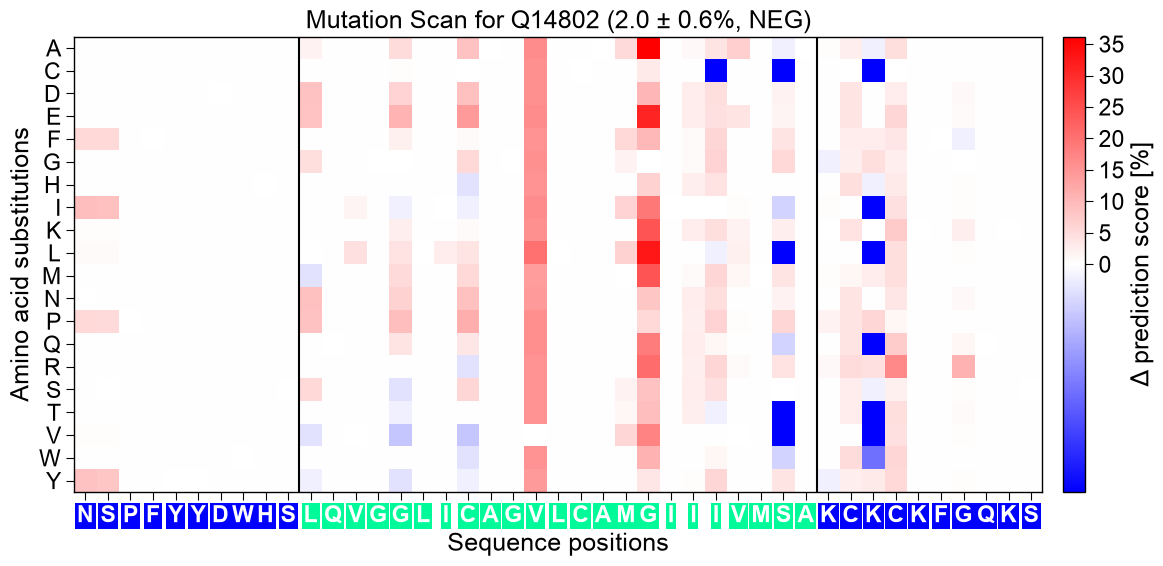

In [1]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False

# Data, CPP features, and a fitted TreeModel that scores each sequence
df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = df_seq["label"].to_list()
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
split_kws = sf.get_split_kws()
df_scales = aa.load_scales()
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws, df_scales=df_scales, verbose=False)
df_feat = cpp.run(labels=labels, n_filter=25)
X = sf.feature_matrix(features=list(df_feat["feature"]), df_parts=df_parts, df_scales=df_scales)
tm = aa.TreeModel().fit(X, labels=labels)
entry = df_seq["entry"].iloc[0]
ts = int(df_seq.set_index("entry").loc[entry, "tmd_start"])

# Model-guided: per-position prediction shift (the mutation-scan heatmap)
df_scan = aa.SeqMut(model=tm).scan(df_seq=df_seq, df_feat=df_feat, region=None)
aa.plot_settings()
aa.SeqMutPlot().mutation_landscape(df_scan=df_scan, entry=entry, class_names=("NEG", "POS"),
                                   figsize=(12, 6))
plt.tight_layout()
plt.show()

Without a bound model the same method shows the model-free ``delta_cpp`` magnitude.

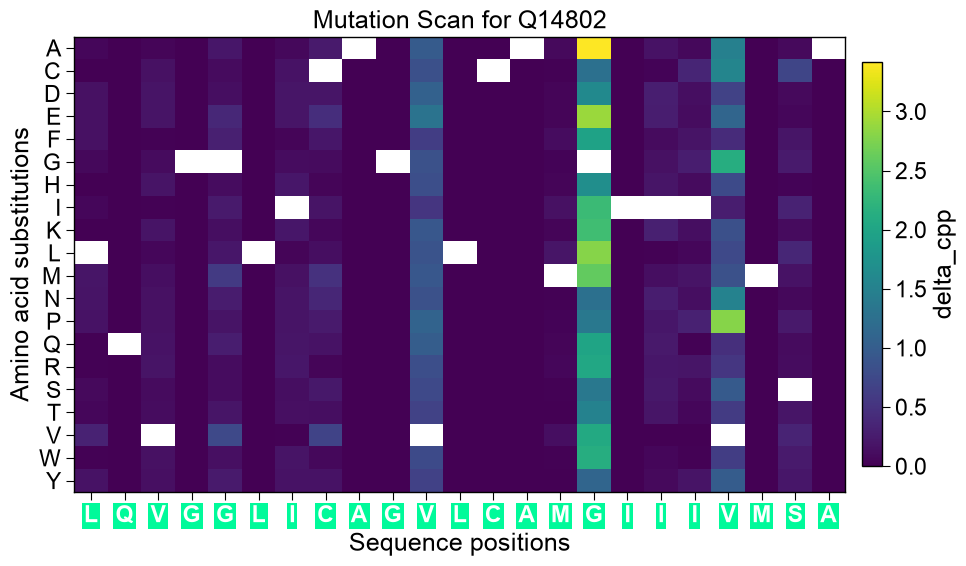

In [2]:
df_scan_free = aa.SeqMut().scan(df_seq=df_seq, df_feat=df_feat, region="tmd")
aa.plot_settings()
aa.SeqMutPlot().mutation_landscape(df_scan=df_scan_free, entry=entry, figsize=(10, 6))
plt.tight_layout()
plt.show()